---
# Building a Demo Machine Learning Model
---

## Machine Learning Development Life Cycle

### `Problem Definition`: Predict the total cost of international education

The goal is to estimate a student's overall education cost using features such as country, city, university, program, degree level, duration, living cost index, visa fee, and insurance fee.

In [1]:
# Install scikit-learn only if it is missing from your notebook environment.
# pip install scikit-learn

In [2]:
# Import the core libraries used for data handling, visualization, and modeling.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

### `Scikit-learn`: A Core Machine Learning Library

- Scikit-learn, often imported as `sklearn`, is a free and open-source Python library for machine learning.
- It provides practical tools for preprocessing data, training models, evaluating performance, and building predictive workflows.
- It is commonly used for regression, classification, clustering, feature selection, and model validation tasks.

## `1. Data Gathering`

- Data gathering is the process of collecting the raw information needed to train, validate, and test a machine learning model.
- Good data should be relevant, accurate, diverse, and representative of the real-world problem.
- In this notebook, the dataset contains international education cost details for different countries, universities, programs, and student expenses.

In [3]:
# Load the international education cost dataset into a pandas DataFrame.
df = pd.read_csv('../datasets/International_Education_Costs.csv')

# Data Exploration, Cleaning, and Preprocessing

## `2. Data Exploration`

- Data exploration is the process of reviewing, summarizing, and visualizing a dataset before model training.
- It helps identify missing values, duplicate records, unusual values, data types, distributions, and relationships between columns.
- This step gives us confidence that the data is suitable for preprocessing and modeling.

In [4]:
# Display the first five rows to preview the dataset.
df.head()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500,70.5,1100,75,550,0.92


In [5]:
# Display the last five rows to inspect the dataset ending.
df.tail()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
902,France,Strasbourg,University of Strasbourg,Data Analytics,Master,2.0,4000,70.2,1000,99,850,0.92
903,Malaysia,Nilai,USIM,Computer Science,Bachelor,3.0,6800,50.5,400,120,400,4.65
904,Saudi Arabia,Al-Ahsa,King Faisal University,Information Systems,Master,2.0,4200,64.2,600,200,800,3.75
905,USA,Seattle,University of Washington,Software Development,PhD,5.0,50000,77.8,2000,160,1500,1.00
906,UK,Nottingham,University of Nottingham,Data Engineering,Master,2.0,34000,61.2,800,485,800,0.79


In [6]:
# Show a random sample of rows to quickly inspect varied records.
df.sample(5)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
74,Australia,Hobart,University of Tasmania,Data Science,Master,2.0,30800,65.4,950,450,650,1.52
400,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,45000,73.8,1700,235,750,1.35
780,Ghana,Kumasi,Kwame Nkrumah University,Software Engineering,PhD,4.0,4200,39.8,250,120,250,12.00
90,Germany,Freiburg,University of Freiburg,Robotics & AI,Master,2.0,500,67.5,800,75,550,0.92
785,Bahrain,Isa Town,Bahrain Polytechnic,Software Development,Bachelor,4.0,6500,61.8,600,130,600,0.38


In [7]:
# Summarize numeric columns with descriptive statistics such as mean, min, max, and quartiles.
df.describe()

,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
count,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000,907.000000
mean,2.836825,16705.016538,64.437486,969.206174,211.396913,700.077178,623.000695
std,0.945449,16582.385275,14.056333,517.154752,143.435740,320.374875,3801.746134
min,1.000000,0.000000,27.800000,150.000000,40.000000,200.000000,0.150000
25%,2.000000,2850.000000,56.300000,545.000000,100.000000,450.000000,0.920000
50%,3.000000,7500.000000,67.500000,900.000000,160.000000,650.000000,1.350000
75%,4.000000,31100.000000,72.200000,1300.000000,240.000000,800.000000,7.150000
max,5.000000,62000.000000,122.400000,2500.000000,490.000000,1500.000000,42150.000000


In [8]:
# Inspect column data types, non-null counts, and memory usage.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float64
 6   Tuition_USD        907 non-null    int64  
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int64  
 9   Visa_Fee_USD       907 non-null    int64  
 10  Insurance_USD      907 non-null    int64  
 11  Exchange_Rate      907 non-null    float64
dtypes: float64(3), int64(4), str(5)
memory usage: 135.6 KB


In [9]:
# Check the number of rows and columns in the dataset.
df.shape

(907, 12)

In [10]:
# Check the total number of cells in the DataFrame: rows multiplied by columns.
df.size

10884

In [11]:
# Count how many records are available for each country.
df['Country'].value_counts()

Country
UK                93
Australia         86
USA               78
Canada            76
Germany           33
                  ..
Taiwan             1
Czech Republic     1
South Africa       1
Nigeria            1
Vietnam            1
Name: count, Length: 71, dtype: int64

In [12]:
# List the unique country names in the dataset.
df['Country'].unique()

<ArrowStringArray>
[               'USA',                 'UK',             'Canada',
          'Australia',            'Germany',              'Japan',
        'Netherlands',          'Singapore',             'France',
        'Switzerland',             'Sweden',            'Denmark',
              'China',        'South Korea',            'Ireland',
        'New Zealand',            'Austria',            'Belgium',
          'Hong Kong',           'Portugal',             'Israel',
             'Taiwan',     'Czech Republic',              'India',
             'Poland',           'Malaysia',              'Spain',
              'Italy',            'Finland',             'Norway',
             'Brazil',             'Turkey',             'Russia',
             'Mexico',             'Greece',           'Thailand',
                'UAE',       'South Africa',              'Egypt',
          'Argentina',          'Indonesia',       'Saudi Arabia',
            'Nigeria',            'Vietnam'

In [13]:
# Filter rows where the country is India.
df[df['Country'] == 'India']

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
44,India,Bangalore,Indian Institute of Science,Computer Science,Master,2.0,2500,45.6,500,200,300,83.20
648,India,Bangalore,Indian Institute of Science,Data Science,PhD,4.0,2000,45.2,300,180,300,82.75
654,India,Mumbai,IIT Bombay,Computer Engineering,Master,2.0,1800,47.5,350,180,300,82.75
659,India,Delhi,IIT Delhi,Artificial Intelligence,PhD,4.0,1900,44.8,320,180,300,82.75
665,India,Chennai,IIT Madras,Software Engineering,Master,2.0,1700,42.4,280,180,300,82.75
671,India,Hyderabad,IIT Hyderabad,Data Analytics,PhD,4.0,1800,41.2,260,180,300,82.75
677,India,Pune,IIT Pune,Computer Science,Master,2.0,1600,40.5,250,180,300,82.75
683,India,Kanpur,IIT Kanpur,Artificial Intelligence,PhD,4.0,1900,39.8,240,180,300,82.75


In [14]:
# Display all column names in the dataset.
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='str')

In [15]:
# Count how many records are available for each city.
df['City'].value_counts()

City
Singapore    18
Melbourne    11
Sydney       11
London       10
Canberra      8
             ..
Tabuk         1
Shah Alam     1
Makkah        1
Nilai         1
Al-Ahsa       1
Name: count, Length: 556, dtype: int64

In [16]:
# List the unique city names in the dataset.
df['City'].unique()

<ArrowStringArray>
['Cambridge',    'London',   'Toronto', 'Melbourne',    'Munich',     'Tokyo',
 'Amsterdam', 'Singapore',     'Paris',    'Zurich',
 ...
 'Cyberjaya',    'Dammam',     'Bangi',      'Taif',    'Melaka',     'Tabuk',
 'Shah Alam',    'Makkah',     'Nilai',   'Al-Ahsa']
Length: 556, dtype: str

In [17]:
# Count records for each academic program.
df['Program'].value_counts()

Program
Computer Science           312
Data Science                82
Computer Engineering        71
Software Engineering        57
Artificial Intelligence     53
                          ... 
Electronics                  1
Electronic Engineering       1
Digital Design               1
Digital Business             1
Data Systems                 1
Name: count, Length: 92, dtype: int64

In [18]:
# Count records for each education level.
df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

In [19]:
# Find the shortest program duration in years.
df['Duration_Years'].min()

np.float64(1.0)

In [20]:
# Find the longest program duration in years.
df['Duration_Years'].max()

np.float64(5.0)

### `isnull()`: Missing Value Detection

- `isnull()` checks every cell in a DataFrame and returns `True` where a value is missing.
- Combining it with `.sum()` gives the missing-value count for each column.

In [21]:
# Check each cell for missing values.
df.isnull()

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
902,False,False,False,False,False,False,False,False,False,False,False,False
903,False,False,False,False,False,False,False,False,False,False,False,False
904,False,False,False,False,False,False,False,False,False,False,False,False
905,False,False,False,False,False,False,False,False,False,False,False,False


In [22]:
# Count missing values in each column.
df.isnull().sum()

Country              0
City                 0
University           0
Program              0
Level                0
Duration_Years       0
Tuition_USD          0
Living_Cost_Index    0
Rent_USD             0
Visa_Fee_USD         0
Insurance_USD        0
Exchange_Rate        0
dtype: int64

In [23]:
# Identify duplicate rows in the dataset.
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
902    False
903    False
904    False
905    False
906    False
Length: 907, dtype: bool

In [24]:
# Review current data types before conversion.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float64
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [25]:
# Convert program duration to float for numeric analysis.
df['Duration_Years'] = df['Duration_Years'].astype("float32")

In [26]:
# Confirm data types after converting duration.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float32
Tuition_USD            int64
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [27]:
# Convert tuition fee to float for calculations and plots.
df['Tuition_USD'] = df['Tuition_USD'].astype("float32")

In [28]:
# Confirm data types after converting tuition.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float32
Tuition_USD          float32
Living_Cost_Index    float64
Rent_USD               int64
Visa_Fee_USD           int64
Insurance_USD          int64
Exchange_Rate        float64
dtype: object

In [29]:
# Convert cost-related columns to integers because these values are stored as whole-dollar amounts.
df['Rent_USD'] = df['Rent_USD'].astype("int32")
df['Visa_Fee_USD'] = df['Visa_Fee_USD'].astype("int32")
df['Insurance_USD'] = df['Insurance_USD'].astype("int32")

In [30]:
# Confirm data types after converting rent, visa fee, and insurance columns.
df.dtypes

Country                  str
City                     str
University               str
Program                  str
Level                    str
Duration_Years       float32
Tuition_USD          float32
Living_Cost_Index    float64
Rent_USD               int32
Visa_Fee_USD           int32
Insurance_USD          int32
Exchange_Rate        float64
dtype: object

In [31]:
# Recheck the cleaned DataFrame structure.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float32
 6   Tuition_USD        907 non-null    float32
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int32  
 9   Visa_Fee_USD       907 non-null    int32  
 10  Insurance_USD      907 non-null    int32  
 11  Exchange_Rate      907 non-null    float64
dtypes: float32(2), float64(2), int32(3), str(5)
memory usage: 117.9 KB


# `Exploratory Data Analysis`

Exploratory Data Analysis, or EDA, is the process of studying data with summaries and charts. It can focus on one column at a time or compare multiple columns to discover trends, patterns, and outliers.

## Univariate Analysis: Count Plot

Univariate analysis studies one variable at a time. A count plot is useful for categorical columns because it shows how often each category appears.

In [32]:
# Identify the top countries by number of records.
df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [33]:
# Display the top countries by record count.
df['Country'].value_counts().head(10)

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [34]:
# Keep records for the main countries used in later visualizations.
country = df[df['Country'].isin(['UK','Australia', 'USA',"Canada", 'Germany', 'France', 'South Korea', 'Netherlands', 'Switzerland', 'Singapore'])]

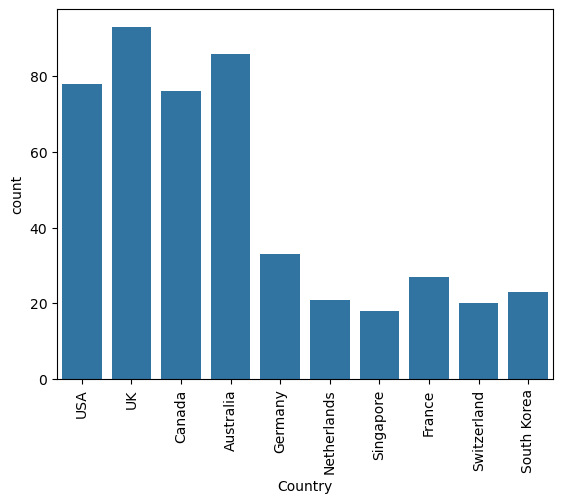

In [35]:
# Plot record counts for the selected countries.
sns.countplot(data = country , x = 'Country')
plt.xticks(rotation = 'vertical')
plt.show()

In [36]:
# Display the most frequent cities in the dataset.
df['City'].value_counts().head()

City
Singapore    18
Melbourne    11
Sydney       11
London       10
Canberra      8
Name: count, dtype: int64

In [37]:
# Filter records for selected study cities.
cities = df[df['City'].isin(['Singapore', 'Melbourne', 'Sydney', 'London', 'Canberra'])]

In [38]:
# Count records by education level.
df['Level'].value_counts()

Level
Master      451
Bachelor    297
PhD         159
Name: count, dtype: int64

<Axes: xlabel='Level', ylabel='count'>

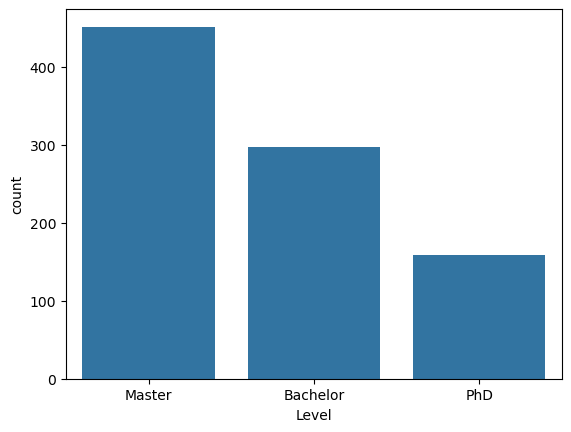

In [39]:
# Plot the distribution of education levels.
sns.countplot(data = df, x='Level')

In [40]:
# Count records by program duration.
df['Duration_Years'].value_counts()

Duration_Years
2.0    423
4.0    276
3.0    171
5.0     17
1.0     16
2.5      3
1.5      1
Name: count, dtype: int64

In [41]:
# Create separate samples for each education level.
d1 = df[df['Level'] == 'Master'].head(150)
d2 = df[df['Level'] == 'Bachelor'].head(150)
d3 = df[df['Level'] == 'PhD'].head(150)

In [42]:
# Combine the sampled education-level DataFrames.
d4 = pd.concat([d1,d2,d3])

In [43]:
# Check the size of the combined sample.
d4.shape

(450, 12)

In [44]:
# Compare against the size of the original DataFrame.
df.shape

(907, 12)

<Axes: xlabel='Duration_Years', ylabel='Count'>

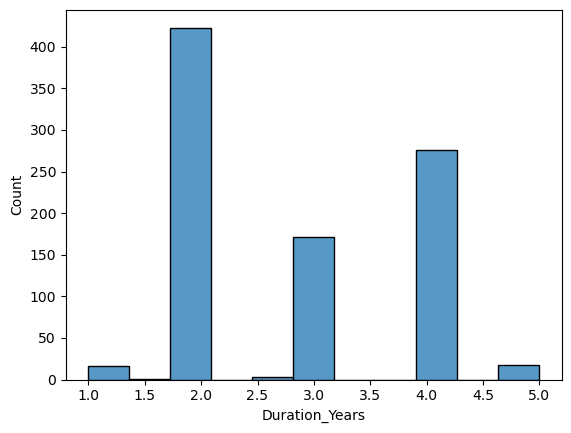

In [45]:
# Plot the distribution of program durations.
sns.histplot(data = df, x='Duration_Years')

<Axes: xlabel='Duration_Years', ylabel='Count'>

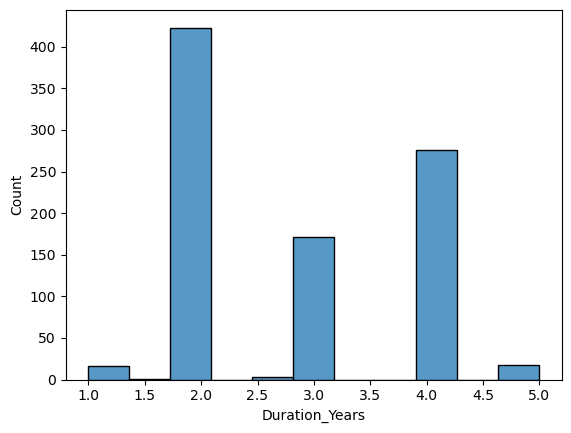

In [46]:
# Plot the duration distribution again for closer inspection.
sns.histplot(data = df , x ='Duration_Years')

In [47]:
# Review columns before choosing fields for visualization.
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='str')

<Axes: xlabel='Tuition_USD', ylabel='Count'>

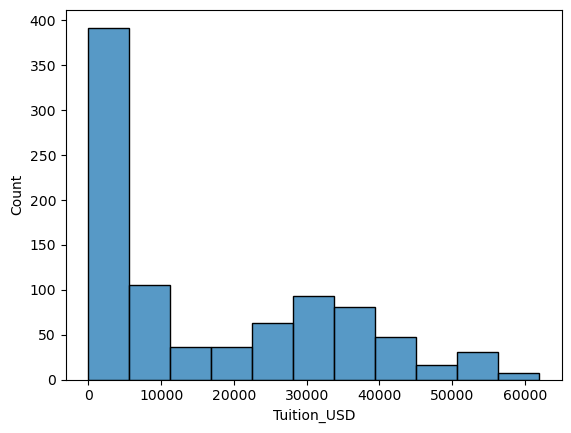

In [48]:
# Plot the distribution of tuition fees.
sns.histplot(data = df, x = 'Tuition_USD')

<Axes: xlabel='Rent_USD', ylabel='Count'>

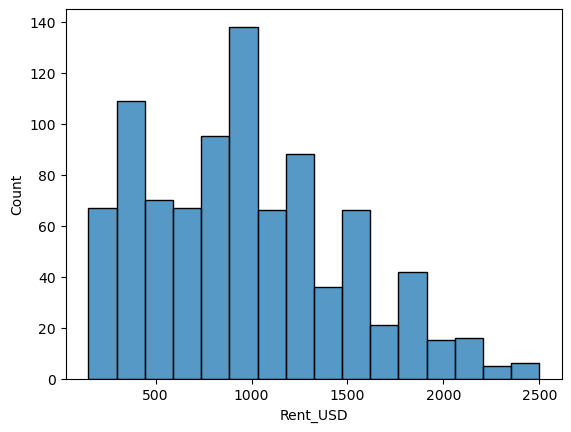

In [49]:
# Plot the distribution of rent costs.
sns.histplot(data = df, x = 'Rent_USD')

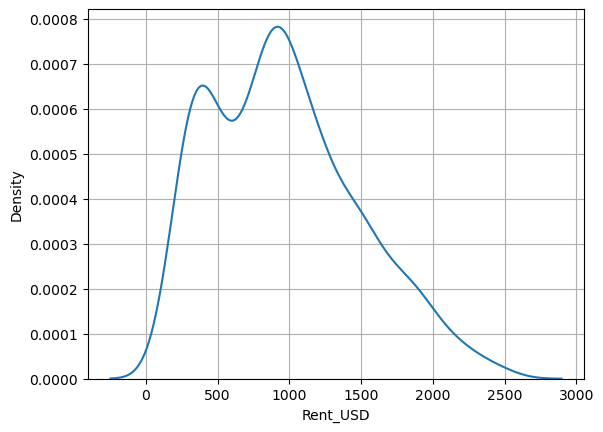

In [50]:
# Plot the rent-cost density curve.
sns.kdeplot(data = df, x = 'Rent_USD')
plt.grid()
plt.show()

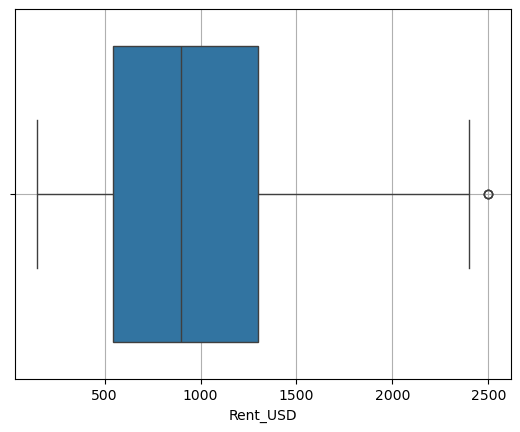

In [51]:
# Use a boxplot to inspect rent spread and outliers.
sns.boxplot(data = df, x = 'Rent_USD')
plt.grid()
plt.show()

# Bivariate Analysis: Categorical and Numerical Columns

Bivariate analysis compares two variables. Here, we compare categorical columns such as country or university with numerical columns such as tuition, visa fee, and duration.

In [52]:
# Review the DataFrame before relationship analysis.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 907 entries, 0 to 906
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Country            907 non-null    str    
 1   City               907 non-null    str    
 2   University         907 non-null    str    
 3   Program            907 non-null    str    
 4   Level              907 non-null    str    
 5   Duration_Years     907 non-null    float32
 6   Tuition_USD        907 non-null    float32
 7   Living_Cost_Index  907 non-null    float64
 8   Rent_USD           907 non-null    int32  
 9   Visa_Fee_USD       907 non-null    int32  
 10  Insurance_USD      907 non-null    int32  
 11  Exchange_Rate      907 non-null    float64
dtypes: float32(2), float64(2), int32(3), str(5)
memory usage: 117.9 KB


In [53]:
# Display column names for selecting plot variables.
df.columns

Index(['Country', 'City', 'University', 'Program', 'Level', 'Duration_Years',
       'Tuition_USD', 'Living_Cost_Index', 'Rent_USD', 'Visa_Fee_USD',
       'Insurance_USD', 'Exchange_Rate'],
      dtype='str')

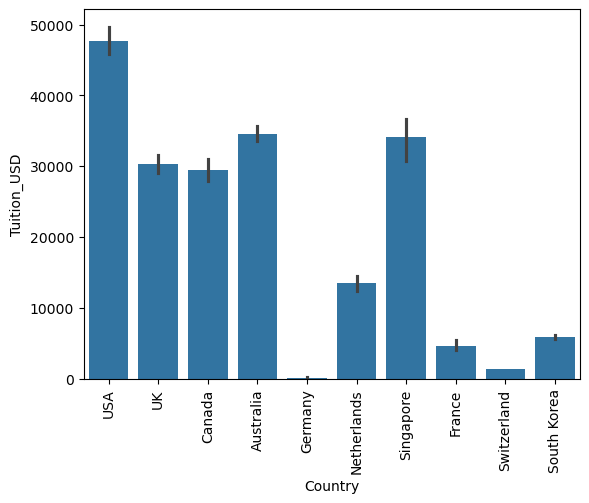

In [54]:
# Compare average tuition fees across the selected countries.
sns.barplot(data = country, x = 'Country', y = 'Tuition_USD')
plt.xticks(rotation='vertical')
plt.show()

In [55]:
# Preview selected country records before plotting.
country.head(10)

,Country,City,University,Program,Level,Duration_Years,Tuition_USD,Living_Cost_Index,Rent_USD,Visa_Fee_USD,Insurance_USD,Exchange_Rate
0,USA,Cambridge,Harvard University,Computer Science,Master,2.0,55400.0,83.5,2200,160,1500,1.00
1,UK,London,Imperial College London,Data Science,Master,1.0,41200.0,75.8,1800,485,800,0.79
2,Canada,Toronto,University of Toronto,Business Analytics,Master,2.0,38500.0,72.5,1600,235,900,1.35
3,Australia,Melbourne,University of Melbourne,Engineering,Master,2.0,42000.0,71.2,1400,450,650,1.52
4,Germany,Munich,Technical University of Munich,Mechanical Engineering,Master,2.0,500.0,70.5,1100,75,550,0.92
6,Netherlands,Amsterdam,University of Amsterdam,Artificial Intelligence,Master,1.0,15800.0,73.2,1500,180,720,0.92
7,Singapore,Singapore,National University of Singapore,Finance,Master,1.5,35000.0,81.1,1900,90,800,1.34
8,France,Paris,Sorbonne University,International Relations,Master,2.0,4500.0,74.6,1400,99,650,0.92
9,Switzerland,Zurich,ETH Zurich,Physics,Master,2.0,1460.0,91.5,2100,88,1200,0.89
13,South Korea,Seoul,Seoul National University,Digital Media,Master,2.0,7200.0,68.7,900,130,500,1320.50


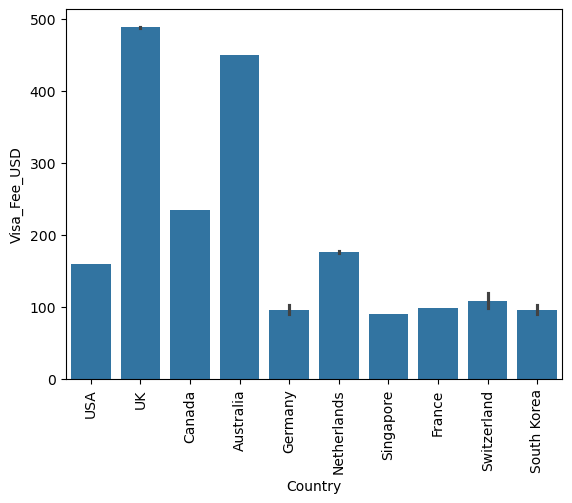

In [56]:
# Compare visa fees across selected countries.
sns.barplot(data = country, x = 'Country', y = 'Visa_Fee_USD')
plt.xticks(rotation=90)
plt.show()

In [57]:
# Display the top universities by record count.
df['University'].value_counts().head(10)

University
University of Washington           6
University of Melbourne            5
Stanford University                5
Australian National University     5
University of Sydney               5
University of Adelaide             5
University of Western Australia    5
Griffith University                5
University of Tasmania             5
University of Newcastle            5
Name: count, dtype: int64

In [58]:
# Filter records for selected universities.
Universities = df[df['University'].isin(['University of Washington','University of Melbourne','Stanford University','Australian National University', 'University of Sydney','University of Adelaide', 'University of Western Australia', 'Griffith University', 'University of Tasmania','University of Newcastl'])]

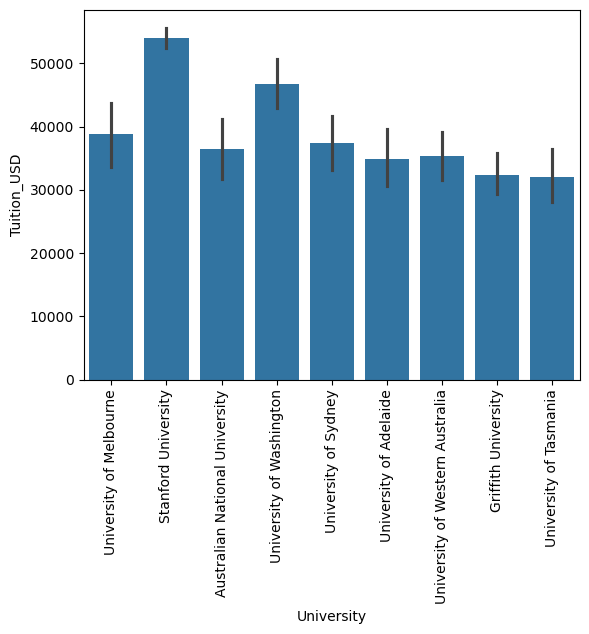

In [59]:
# Compare tuition fees across selected universities.
sns.barplot(data = Universities, x = 'University', y ='Tuition_USD')
plt.xticks(rotation='vertical')
plt.show()

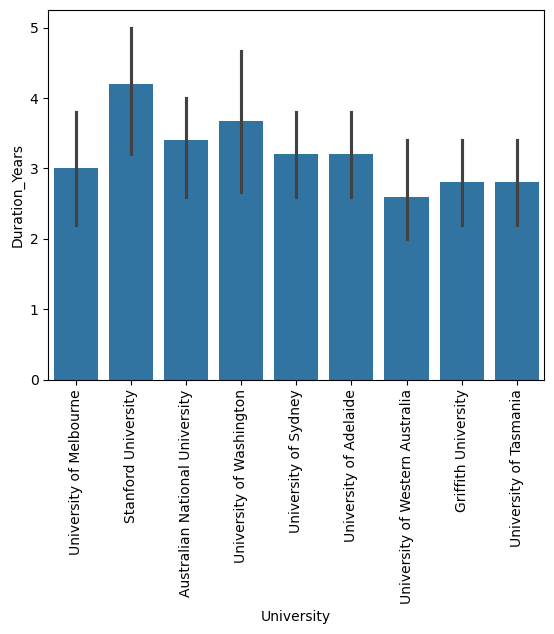

In [60]:
# Compare program duration across selected universities.
sns.barplot(data = Universities, x = 'University', y ='Duration_Years')
plt.xticks(rotation='vertical')
plt.show()

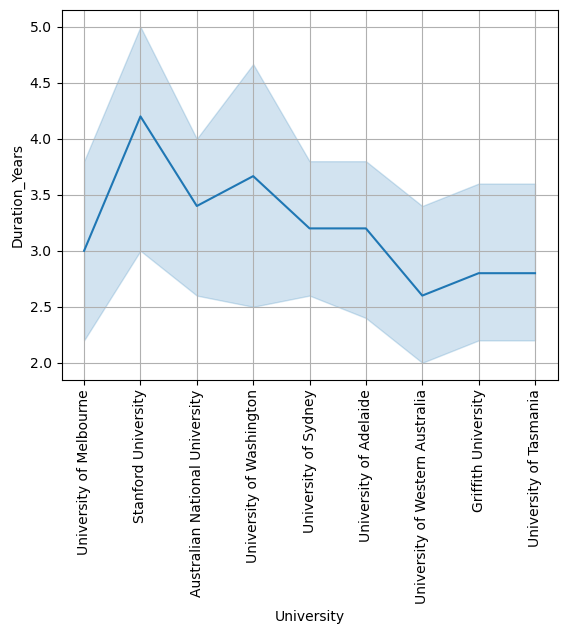

In [61]:
# Show duration trends across selected universities.
sns.lineplot(data = Universities, x = 'University', y ='Duration_Years')
plt.xticks(rotation='vertical')
plt.grid()
plt.show()

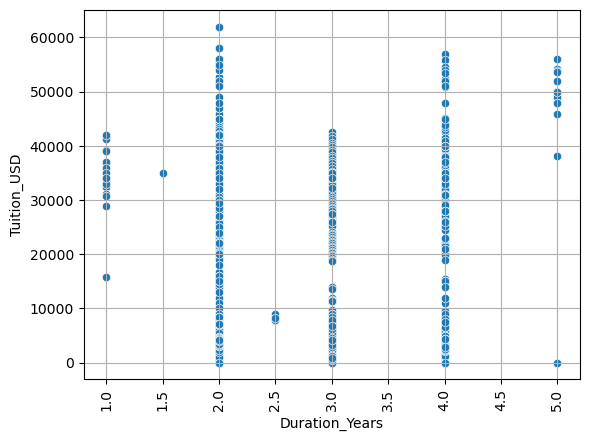

In [62]:
# Plot the relationship between duration and tuition.
sns.scatterplot(data = df, x = 'Duration_Years', y ='Tuition_USD')
plt.xticks(rotation='vertical')
plt.grid()
plt.show()

# Top Countries and Universities: Tuition Fee Heatmap

A heatmap helps compare average tuition values across two categorical dimensions: country and university.

In [63]:
# Recheck selected-country record counts for the heatmap.
country['Country'].value_counts()

Country
UK             93
Australia      86
USA            78
Canada         76
Germany        33
France         27
South Korea    23
Netherlands    21
Switzerland    20
Singapore      18
Name: count, dtype: int64

In [64]:
# Find the top universities inside the selected countries.
country['University'].value_counts().head(10)

University
University of Washington           6
University of Melbourne            5
Stanford University                5
Australian National University     5
University of Sydney               5
University of Adelaide             5
University of Western Australia    5
Griffith University                5
University of Tasmania             5
University of Newcastle            5
Name: count, dtype: int64

In [65]:
# Filter selected-country data to the chosen universities.
Universities = country[country['University'].isin(['University of Washington','University of Melbourne','Stanford University','Australian National University', 'University of Sydney','University of Adelaide', 'University of Western Australia', 'Griffith University', 'University of Tasmania','University of Newcastl'])]

In [66]:
# Create a pivot table with countries as rows, universities as columns, and average tuition as values.
data = Universities.pivot_table(index = 'Country', columns='University', values='Tuition_USD', aggfunc='mean')


<Axes: xlabel='University', ylabel='Country'>

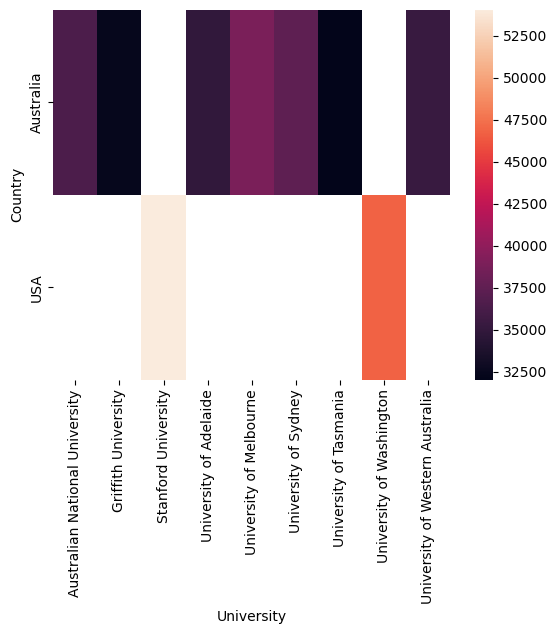

In [67]:
# Visualize average tuition by country and university as a heatmap.
sns.heatmap(data)